<h2><span style="color:darkviolet">Argon Solid Phase Simulations</span></h2>

This notebook aims to reproduce the results obtained from Molecular Dynamics and Markov Chain Monte Carlo simulations for Argon, focusing on the **solid phase**. The objective is to achieve and study a thermodynamically equilibrated configuration under the following reduced conditions, derived from the input parameters:

- **Reduced Density**: $\rho^\star = 1.1$
- **Reduced Temperature**: $T^\star = 0.8$
- **Cut-off Radius**: $r_c = 2.2 \sigma$

Since the initial configuration of the system is a FCC lattice, which is characteristic of a solid phase, the system is already in a configuration representative of the target phase. Consequently, the **equilibration** simulation must be run for a **shorter** duration compared to a gas and a liquid phase simulation. Since liquid phase equilibration, made up by $5000$ steps, runs for a time period around $10$ seconds, I have decided to run an equilibration simulation of the same length for the solid phase, even though it is not necessary, to be completely sure the system is equilibrated.

The parameters used for the equilibration run were:

<div align="center">

| Parameters | NVE equilibration | NVT equilibration |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 0 | 0 |
| TEMP | 1.5457 | 0.8 |
| NPART | 108 | 108 |
| RHO | 1.1 | 1.1 |
| R_CUT | 2.2 | 2.2 |
| DELTA | 0.001 | 0.056 |
| NBLOCKS | 5000 | 5000 |
| NSTEPS | 1 | 1 |
| TAILS | 1 | 1 |

</div>

To determine the system's **correlation time** and the **optimal block length** for statistical analysis, a $500000$ steps simulation was executed, starting from the equilibrated system configuration.

The input parameters for this run were:

<div align="center">

| Parameters | NVE autocorrelation | NVT autocorrelation |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 1 | 1 |
| TEMP | 0.802477 | 0.8 |
| NPART | 108 | 108 |
| RHO | 1.1 | 1.1 |
| R_CUT | 2.2 | 2.2 |
| DELTA | 0.001 | 0.056 |
| NBLOCKS | 500000 | 500000 |
| NSTEPS | 1 | 1 |
| TAILS | 1 | 1 |

</div>

Once the system has been properly equilibrated and the block lenght was calculated, the objective is:

- To graphically represent the progressive block averages for both the potential energy per particle and the pressure, including their respective statistical uncertainties.

- To produce the Radial Distribution Function ($g(r)$) plots for both ensembles (NVE and NVT).

The input parameters used for the final production simulations were:

<div align="center">

| Parameters | NVE simulation | NVT simulation |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 1 | 1 |
| TEMP | 0.802477 | 0.8 |
| NPART | 108 | 108 |
| RHO | 1.1 | 1.1 |
| R_CUT | 2.2 | 2.2 |
| DELTA | 0.001 | 0.056 |
| NBLOCKS | 100 | 100 |
| NSTEPS | 3000 | 3000 |
| TAILS | 1 | 1 |

</div>

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

In [51]:
equil_step = 5000
acf_step = 10000

In [52]:
temp = np.loadtxt("MD_NVE/solid/equilibration/OUTPUT/temperature.dat", usecols=(1), unpack=True)
accept = np.loadtxt("MC_NVT/solid/equilibration/OUTPUT/acceptance.dat", usecols=(1), unpack=True)
poten_en = np.loadtxt("MC_NVT/solid/equilibration/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
x = np.arange(0, equil_step)

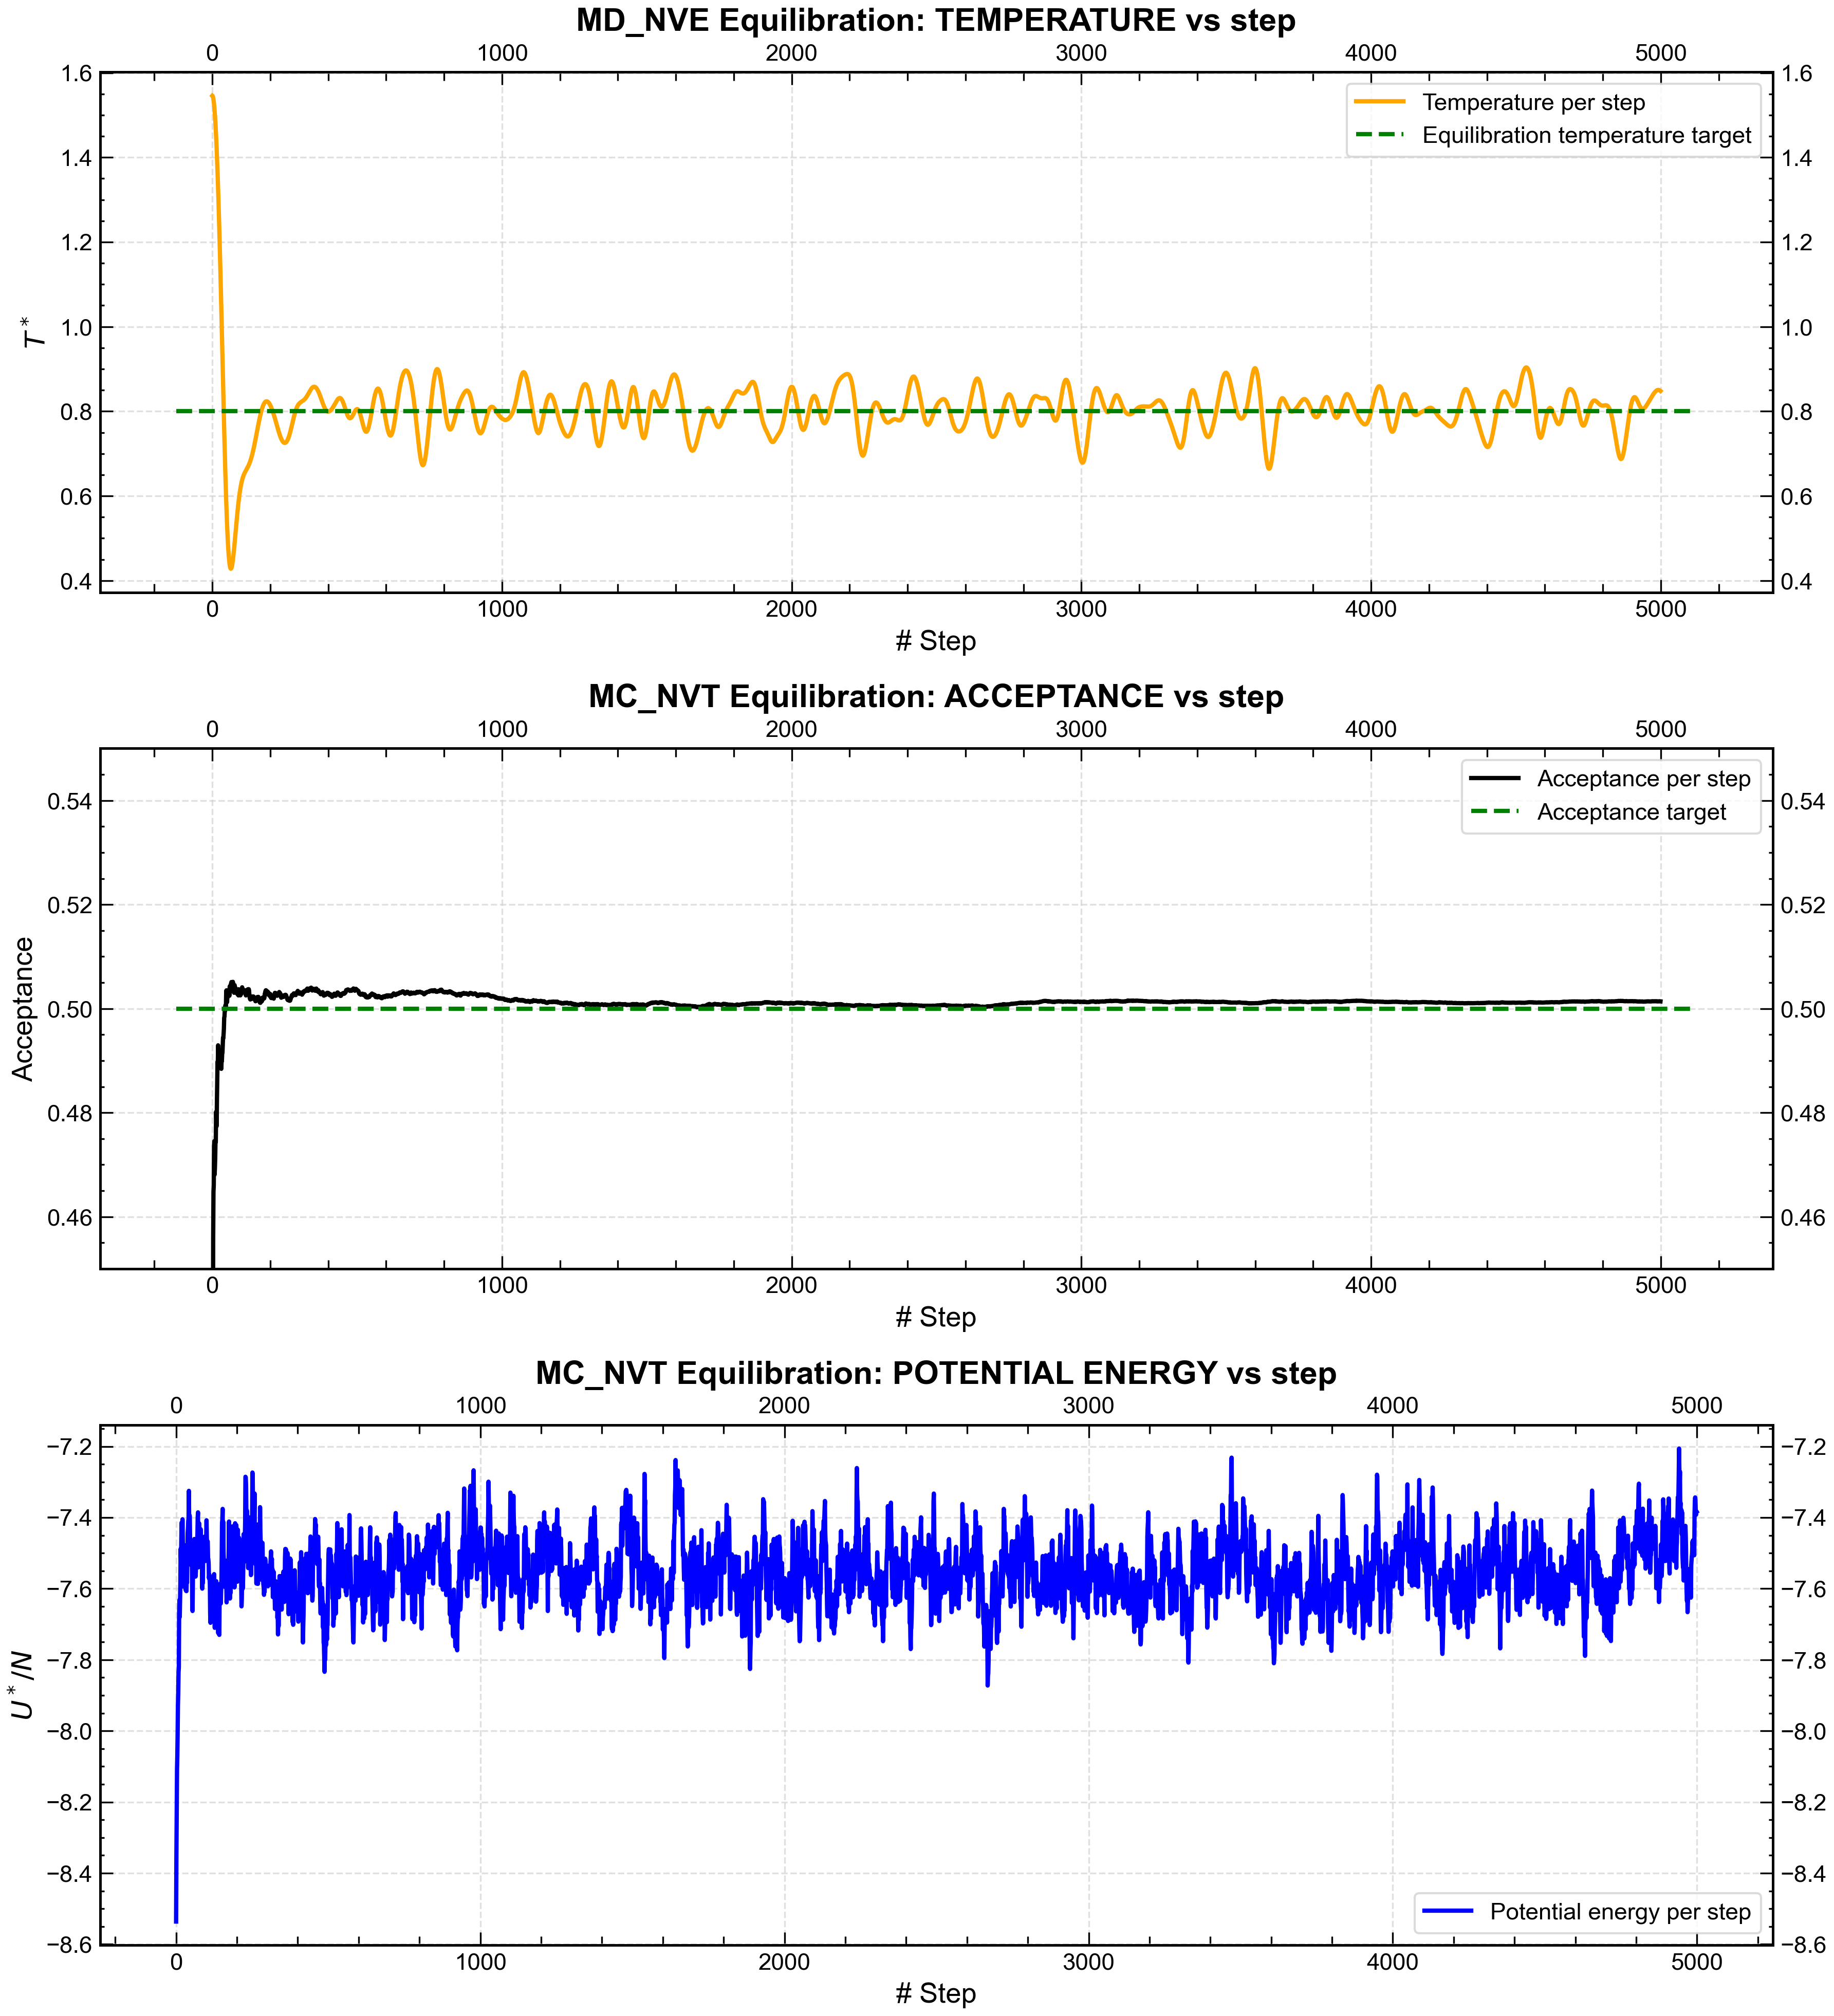

In [53]:
fig, axs = plt.subplots(3,1, figsize=(14,15))

axs[0].set_title("MD_NVE Equilibration: TEMPERATURE vs step")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$T^*$")
axs[0].plot(x, temp, color="orange", label="Temperature per step")
axs[0].hlines(0.8, -125, x[-1]+125, color="green", linestyle="--", label="Equilibration temperature target")
axs[0].legend()

axs[1].set_title("MC_NVT Equilibration: ACCEPTANCE vs step")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel("Acceptance")
axs[1].plot(x, accept, color="black", label="Acceptance per step")
axs[1].hlines(0.5, -125, x[-1]+125, color="green", linestyle="--", label="Acceptance target")
axs[1].set_ylim(0.45, 0.55)
axs[1].legend()

axs[2].set_title("MC_NVT Equilibration: POTENTIAL ENERGY vs step")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$U^*/N$")
axs[2].plot(x, poten_en, color="blue", label="Potential energy per step")
axs[2].legend()

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.3, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/solid/equilibration/equilibration.png")

plt.show()

<h4>Conclusions</h4>

It can be observed from the graphs that, as expected, the solid phase of Argon requires short equilibration times. After approximately $2000$ steps, the temperature of the NVE ensemble, starting from an initial temperature $T^{\star}_{st} = 1.5457$, reached the simulation temperature $T^{\star} = 0.8$, and from that point onward, it continues to fluctuate closely around this value. Regarding the NVT ensemble, by setting a Metropolis step size $\Delta = 0.056$, the acceptance rate saturates at the conventionally required value of $50\%$.

In [54]:
potential_NVE = np.loadtxt("MD_NVE/solid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]
potential_NVT = np.loadtxt("MC_NVT/solid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]

var_NVE = np.var(potential_NVE)
var_NVT = np.var(potential_NVT)

unbiased_acf_NVE = functions.unbiased_acf(potential_NVE, var_NVE)
unbiased_acf_NVT = functions.unbiased_acf(potential_NVT, var_NVT)

In [56]:
barlett_dampling_time = acf_step/10
unbiased_acf_NVE_barlett = unbiased_acf_NVE * [functions.barlett_window(t, barlett_dampling_time) for t in range(acf_step)]
unbiased_acf_NVT_barlett = unbiased_acf_NVT * [functions.barlett_window(t, barlett_dampling_time) for t in range(acf_step)]

In [57]:
# Calcolo della media campionaria
mean_NVE = np.mean(potential_NVE)
mean_NVT = np.mean(potential_NVT)

# Demediazione per utilizzare formula del libro
potential_NVE = potential_NVE - mean_NVE
potential_NVT = potential_NVT - mean_NVT

# Calcolo della varianza per evitare calcoli superflui nella funzione di autocorrelazione
var_NVE = np.var(potential_NVE)
var_NVT = np.var(potential_NVT)

biased_acf_NVE = functions.biased_acf(potential_NVE, var_NVE)
biased_acf_NVT = functions.biased_acf(potential_NVT, var_NVT)

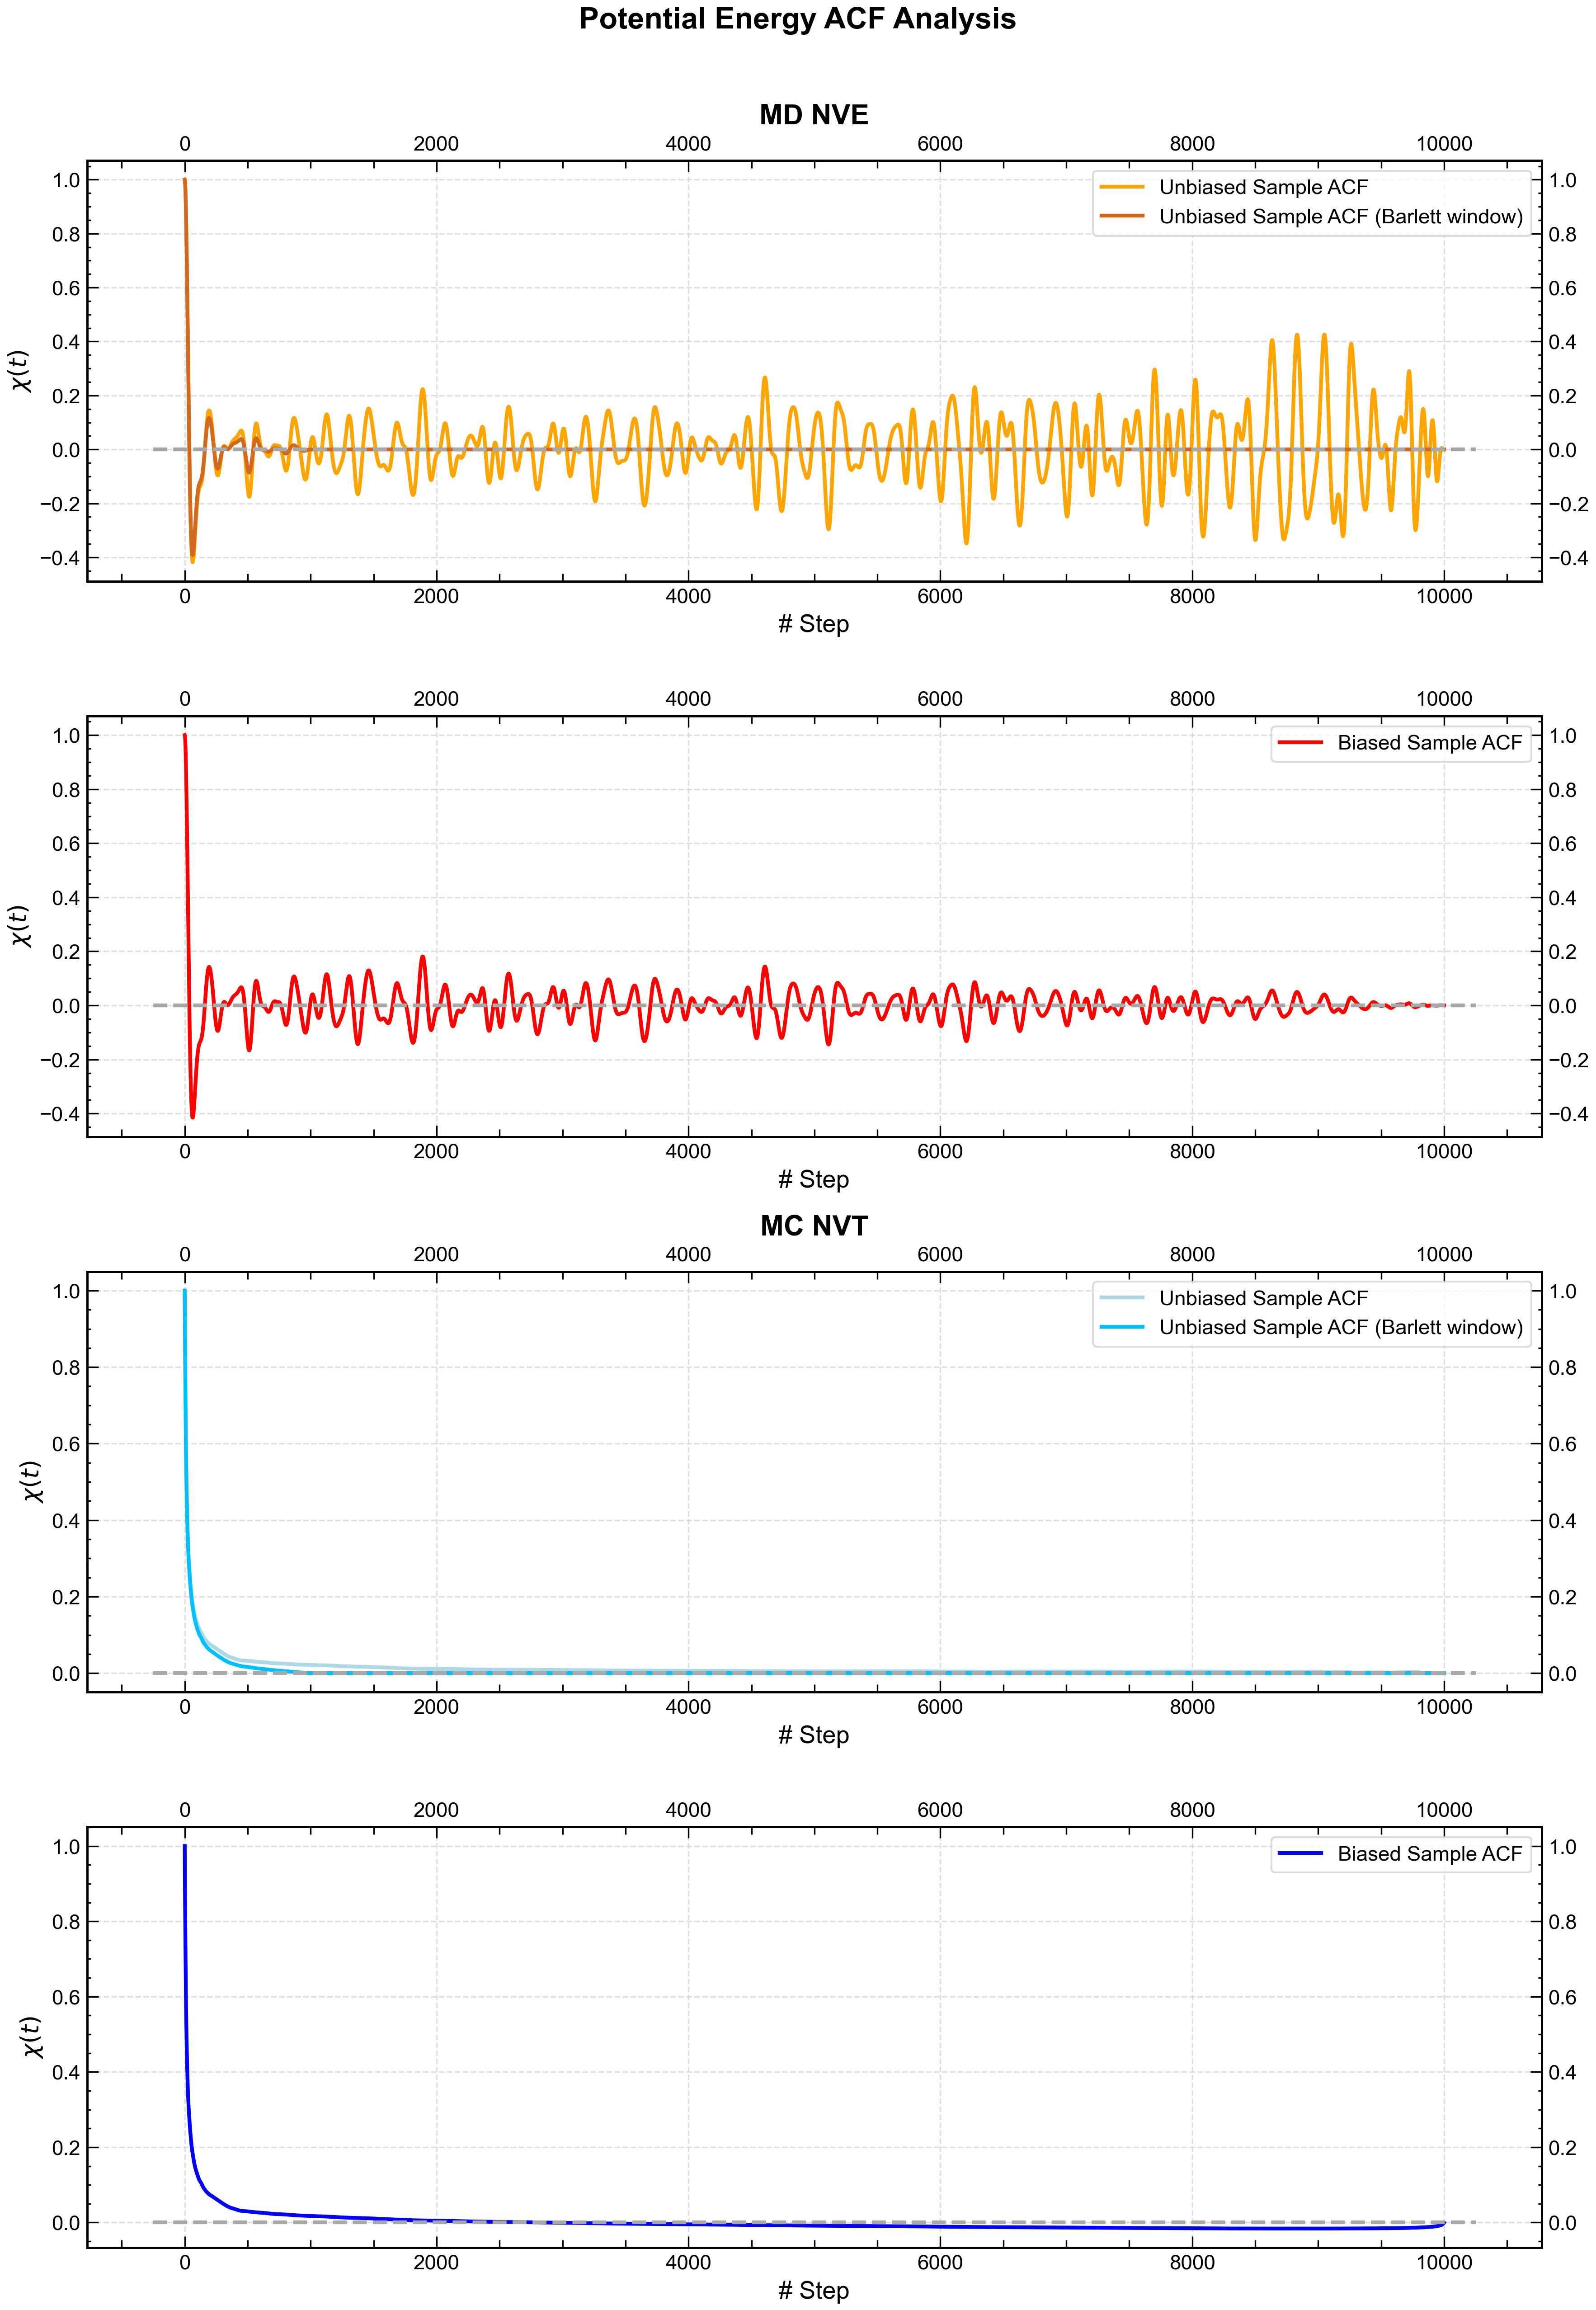

NVE Correlation time from unbiased sample ACF : τ ≈ 43.77 steps
NVE Correlation time from biased sample ACF : τ ≈ 43.72 steps
NVT Correlation time from unbiased sample ACF : τ ≈ 241.58 steps
NVT Correlation time from biased sample ACF : τ ≈ 152.51 steps


In [58]:
# Assumo che acf_step, unbiased_acf_NVE, ecc. siano stati definiti
x = np.arange(0, acf_step) 

fig, axs = plt.subplots(4, 1, figsize=(12, 18)) 

fig.suptitle("Potential Energy ACF Analysis", fontweight="bold", fontsize=16)

axs[0].set_title("MD NVE")
axs[0].plot(x, unbiased_acf_NVE, color="orange", label="Unbiased Sample ACF")
axs[0].plot(x, unbiased_acf_NVE_barlett, color="chocolate", label="Unbiased Sample ACF (Barlett window)")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$\chi(t)$")
# axs[0].set_xlim(-500,10500)
# axs[0].set_ylim(-0.5,1.2)
axs[0].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[0].legend()

axs[1].plot(x, biased_acf_NVE, color="red", label="Biased Sample ACF")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel(r"$\chi(t)$")
# axs[1].set_xlim(-500,10500)
# axs[1].set_ylim(-0.5,1.2)
axs[1].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[1].legend()

axs[2].set_title("MC NVT")
axs[2].plot(x, unbiased_acf_NVT, color="lightblue", label="Unbiased Sample ACF")
axs[2].plot(x, unbiased_acf_NVT_barlett, color="deepskyblue", label="Unbiased Sample ACF (Barlett window)")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$\chi(t)$")
# axs[2].set_xlim(-500,10500)
# axs[2].set_ylim(-0.5,1.2)
axs[2].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[2].legend()

axs[3].plot(x, biased_acf_NVT, color="blue", label="Biased Sample ACF")
axs[3].set_xlabel("# Step")
axs[3].set_ylabel(r"$\chi(t)$")
# axs[3].set_xlim(-500,10500)
# axs[3].set_ylim(-0.5,1.2)
axs[3].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[3].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])

fig.savefig("plot/solid/autocorrelation/autocorrelation_pot_energy.png")
plt.show()

NVE_ct_unbias = functions.integrated_ac_time(unbiased_acf_NVE)
NVE_ct_bias = functions.integrated_ac_time(biased_acf_NVE)
NVT_ct_unbias = functions.integrated_ac_time(unbiased_acf_NVT)
NVT_ct_bias = functions.integrated_ac_time(biased_acf_NVT)

print(f"NVE Correlation time from unbiased sample ACF : τ ≈ {NVE_ct_unbias:.2f} steps")
print(f"NVE Correlation time from biased sample ACF : τ ≈ {NVE_ct_bias:.2f} steps")
print(f"NVT Correlation time from unbiased sample ACF : τ ≈ {NVT_ct_unbias:.2f} steps")
print(f"NVT Correlation time from biased sample ACF : τ ≈ {NVT_ct_bias:.2f} steps")

In [59]:
# Dataset loading
potential_NVE = np.loadtxt("MD_NVE/solid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
potential_NVT = np.loadtxt("MC_NVT/solid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)

# Minimum block size
L_min = 1
# Maximum block size
L_max = 10000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err_NVE = np.zeros(num_L)
err_NVT = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err_NVE[i] = functions.data_blocking(potential_NVE, L)
    err_NVT[i] = functions.data_blocking(potential_NVT, L)

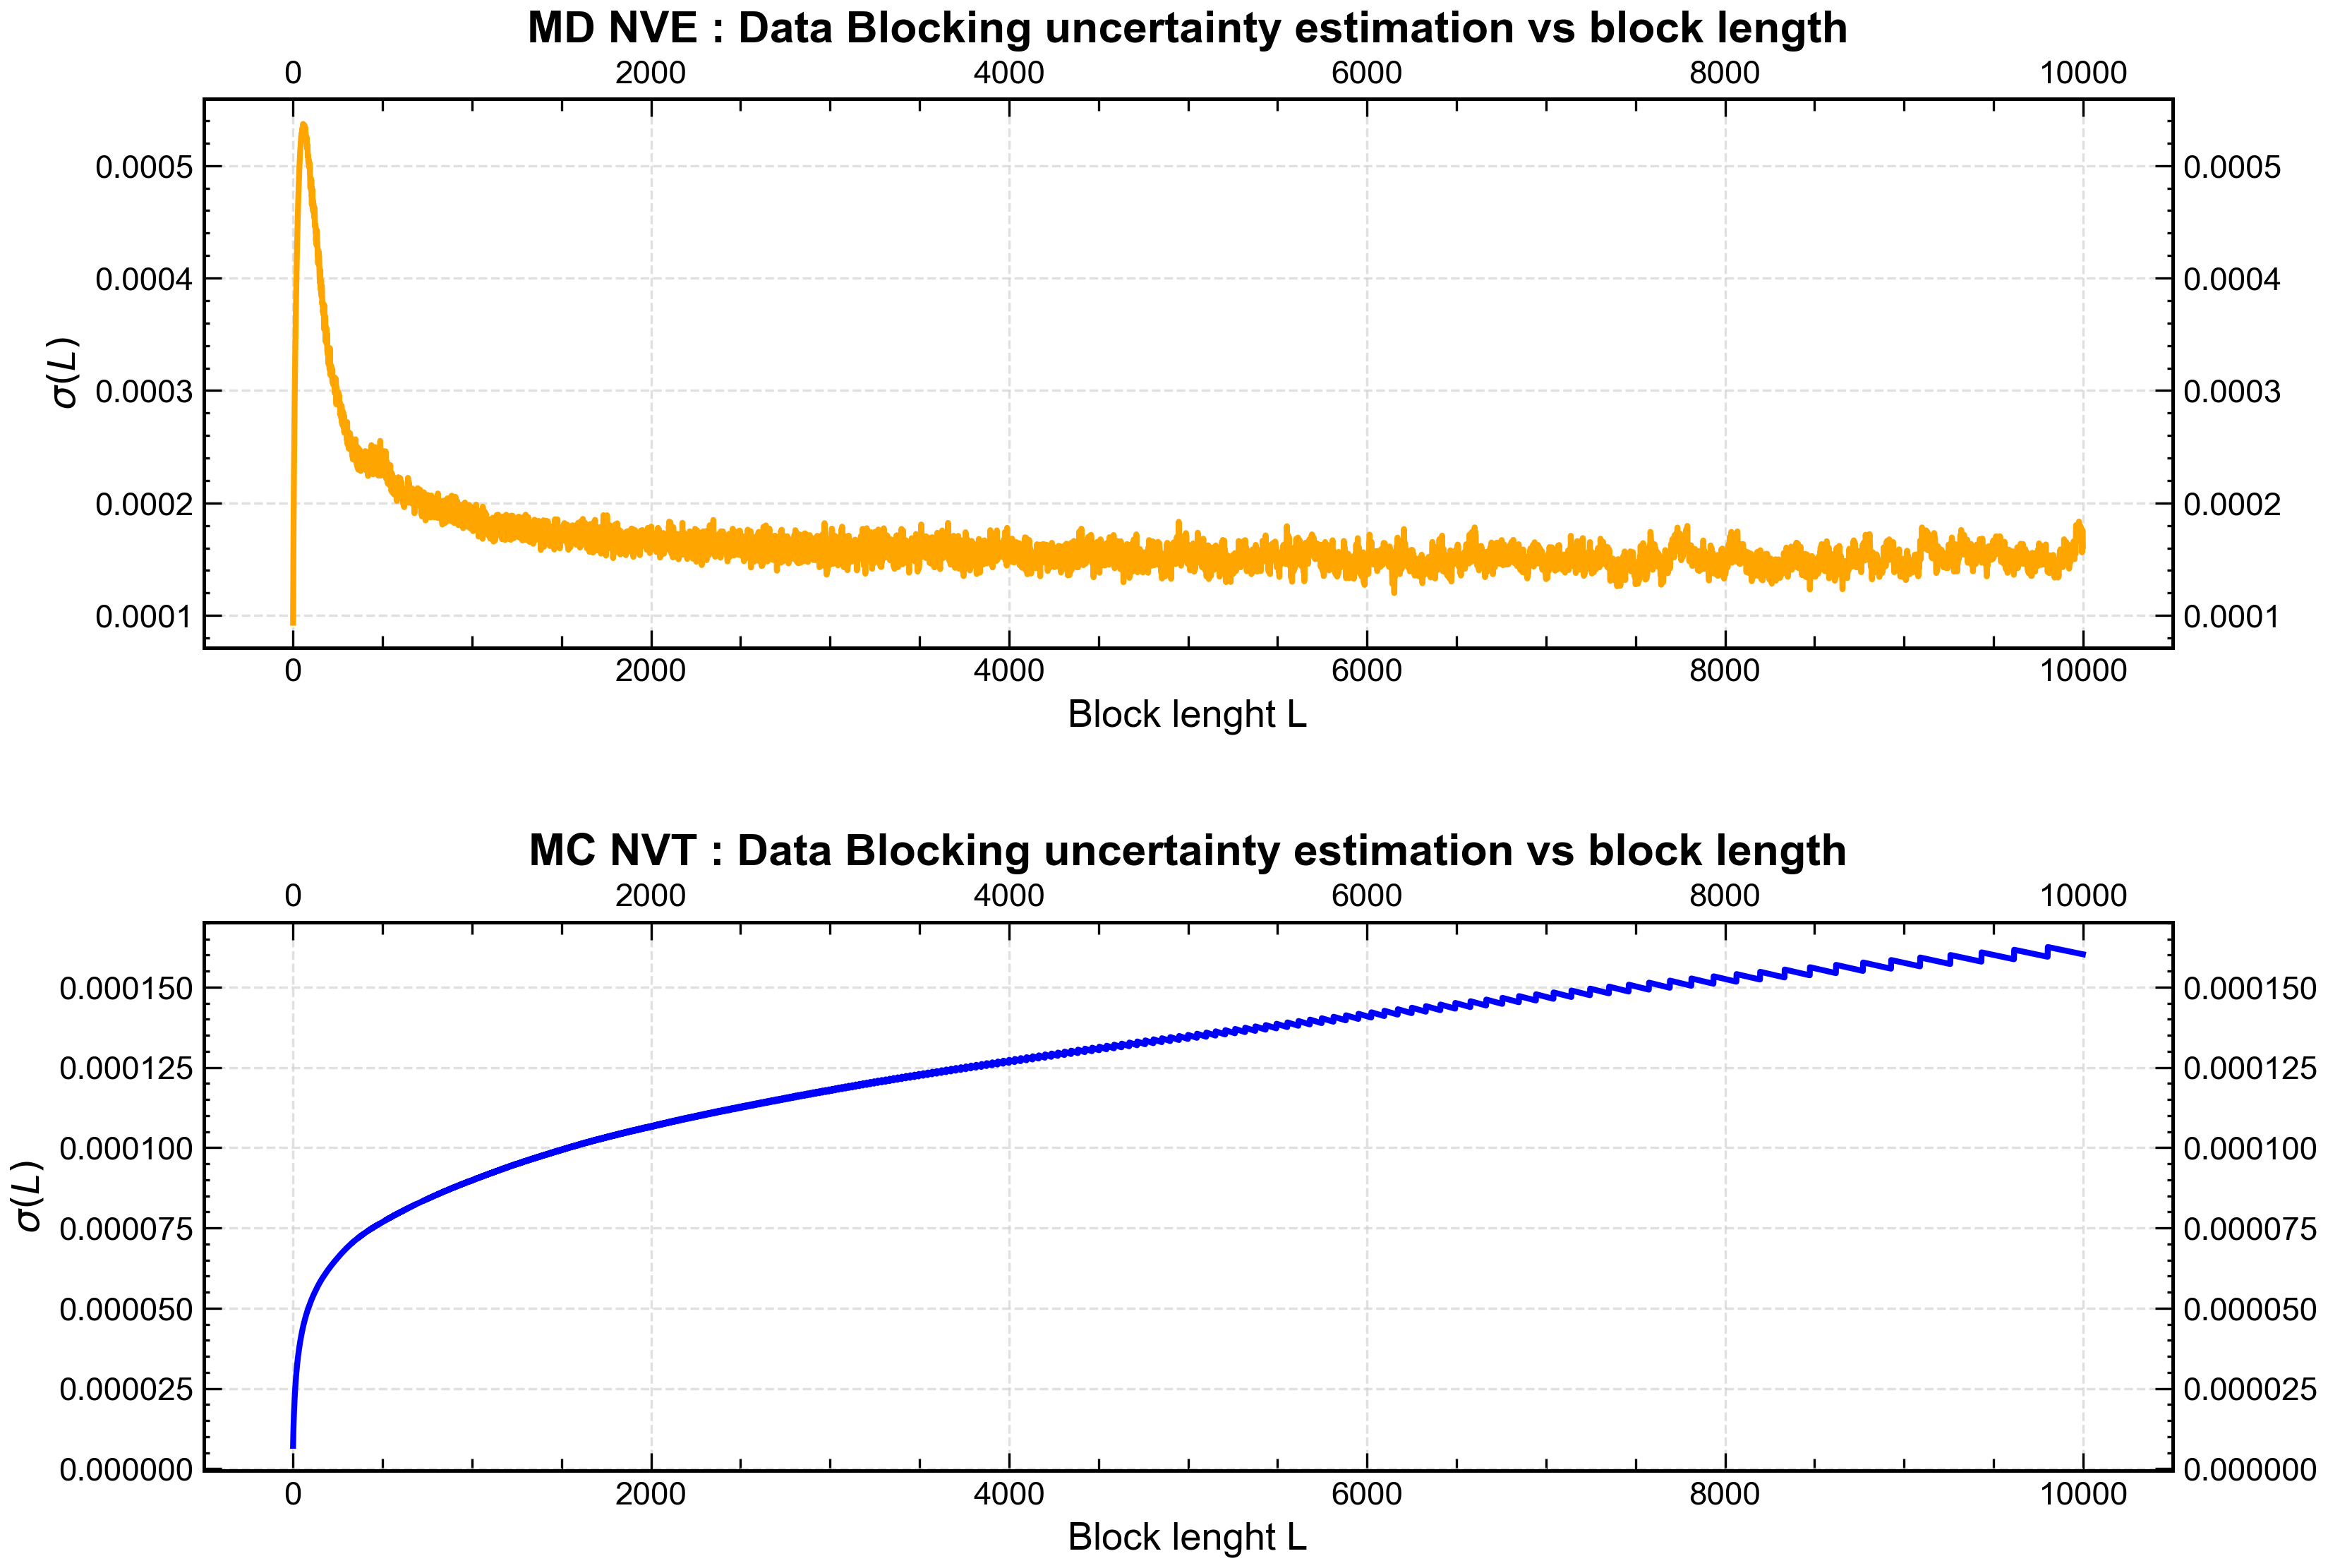

In [60]:
x = np.arange(0, len(err_NVE))

fig, axs = plt.subplots(2, 1, figsize=(12,8))

axs[0].set_title("MD NVE : Data Blocking uncertainty estimation vs block length")
axs[0].plot(x, err_NVE, color="orange")
axs[0].set_xlabel("Block lenght L")
axs[0].set_ylabel(r"$\sigma (L)$")

axs[1].set_title("MC NVT : Data Blocking uncertainty estimation vs block length")
axs[1].plot(x, err_NVT, color="blue")
axs[1].set_xlabel("Block lenght L")
axs[1].set_ylabel(r"$\sigma (L)$")

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.5, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/solid/autocorrelation/data_block_error.png")

plt.show()

In [61]:
blocks, pot_en_NVE, pot_en_err_NVE = np.loadtxt("MD_NVE/solid/run/OUTPUT/potential_energy.dat", usecols=(0,2,3), unpack=True)
press_NVE, press_err_NVE = np.loadtxt("MD_NVE/solid/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
bin_center, gofr_NVE, gofr_err_NVE = np.loadtxt("MD_NVE/solid/run/OUTPUT/gofr.dat", usecols=(1,3,4), unpack=True)
pot_en_NVT, pot_en_err_NVT = np.loadtxt("MC_NVT/solid/run/OUTPUT/potential_energy.dat", usecols=(2,3), unpack=True)
press_NVT, press_err_NVT = np.loadtxt("MC_NVT/solid/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
gofr_NVT, gofr_err_NVT = np.loadtxt("MC_NVT/solid/run/OUTPUT/gofr.dat", usecols=(3,4), unpack=True)

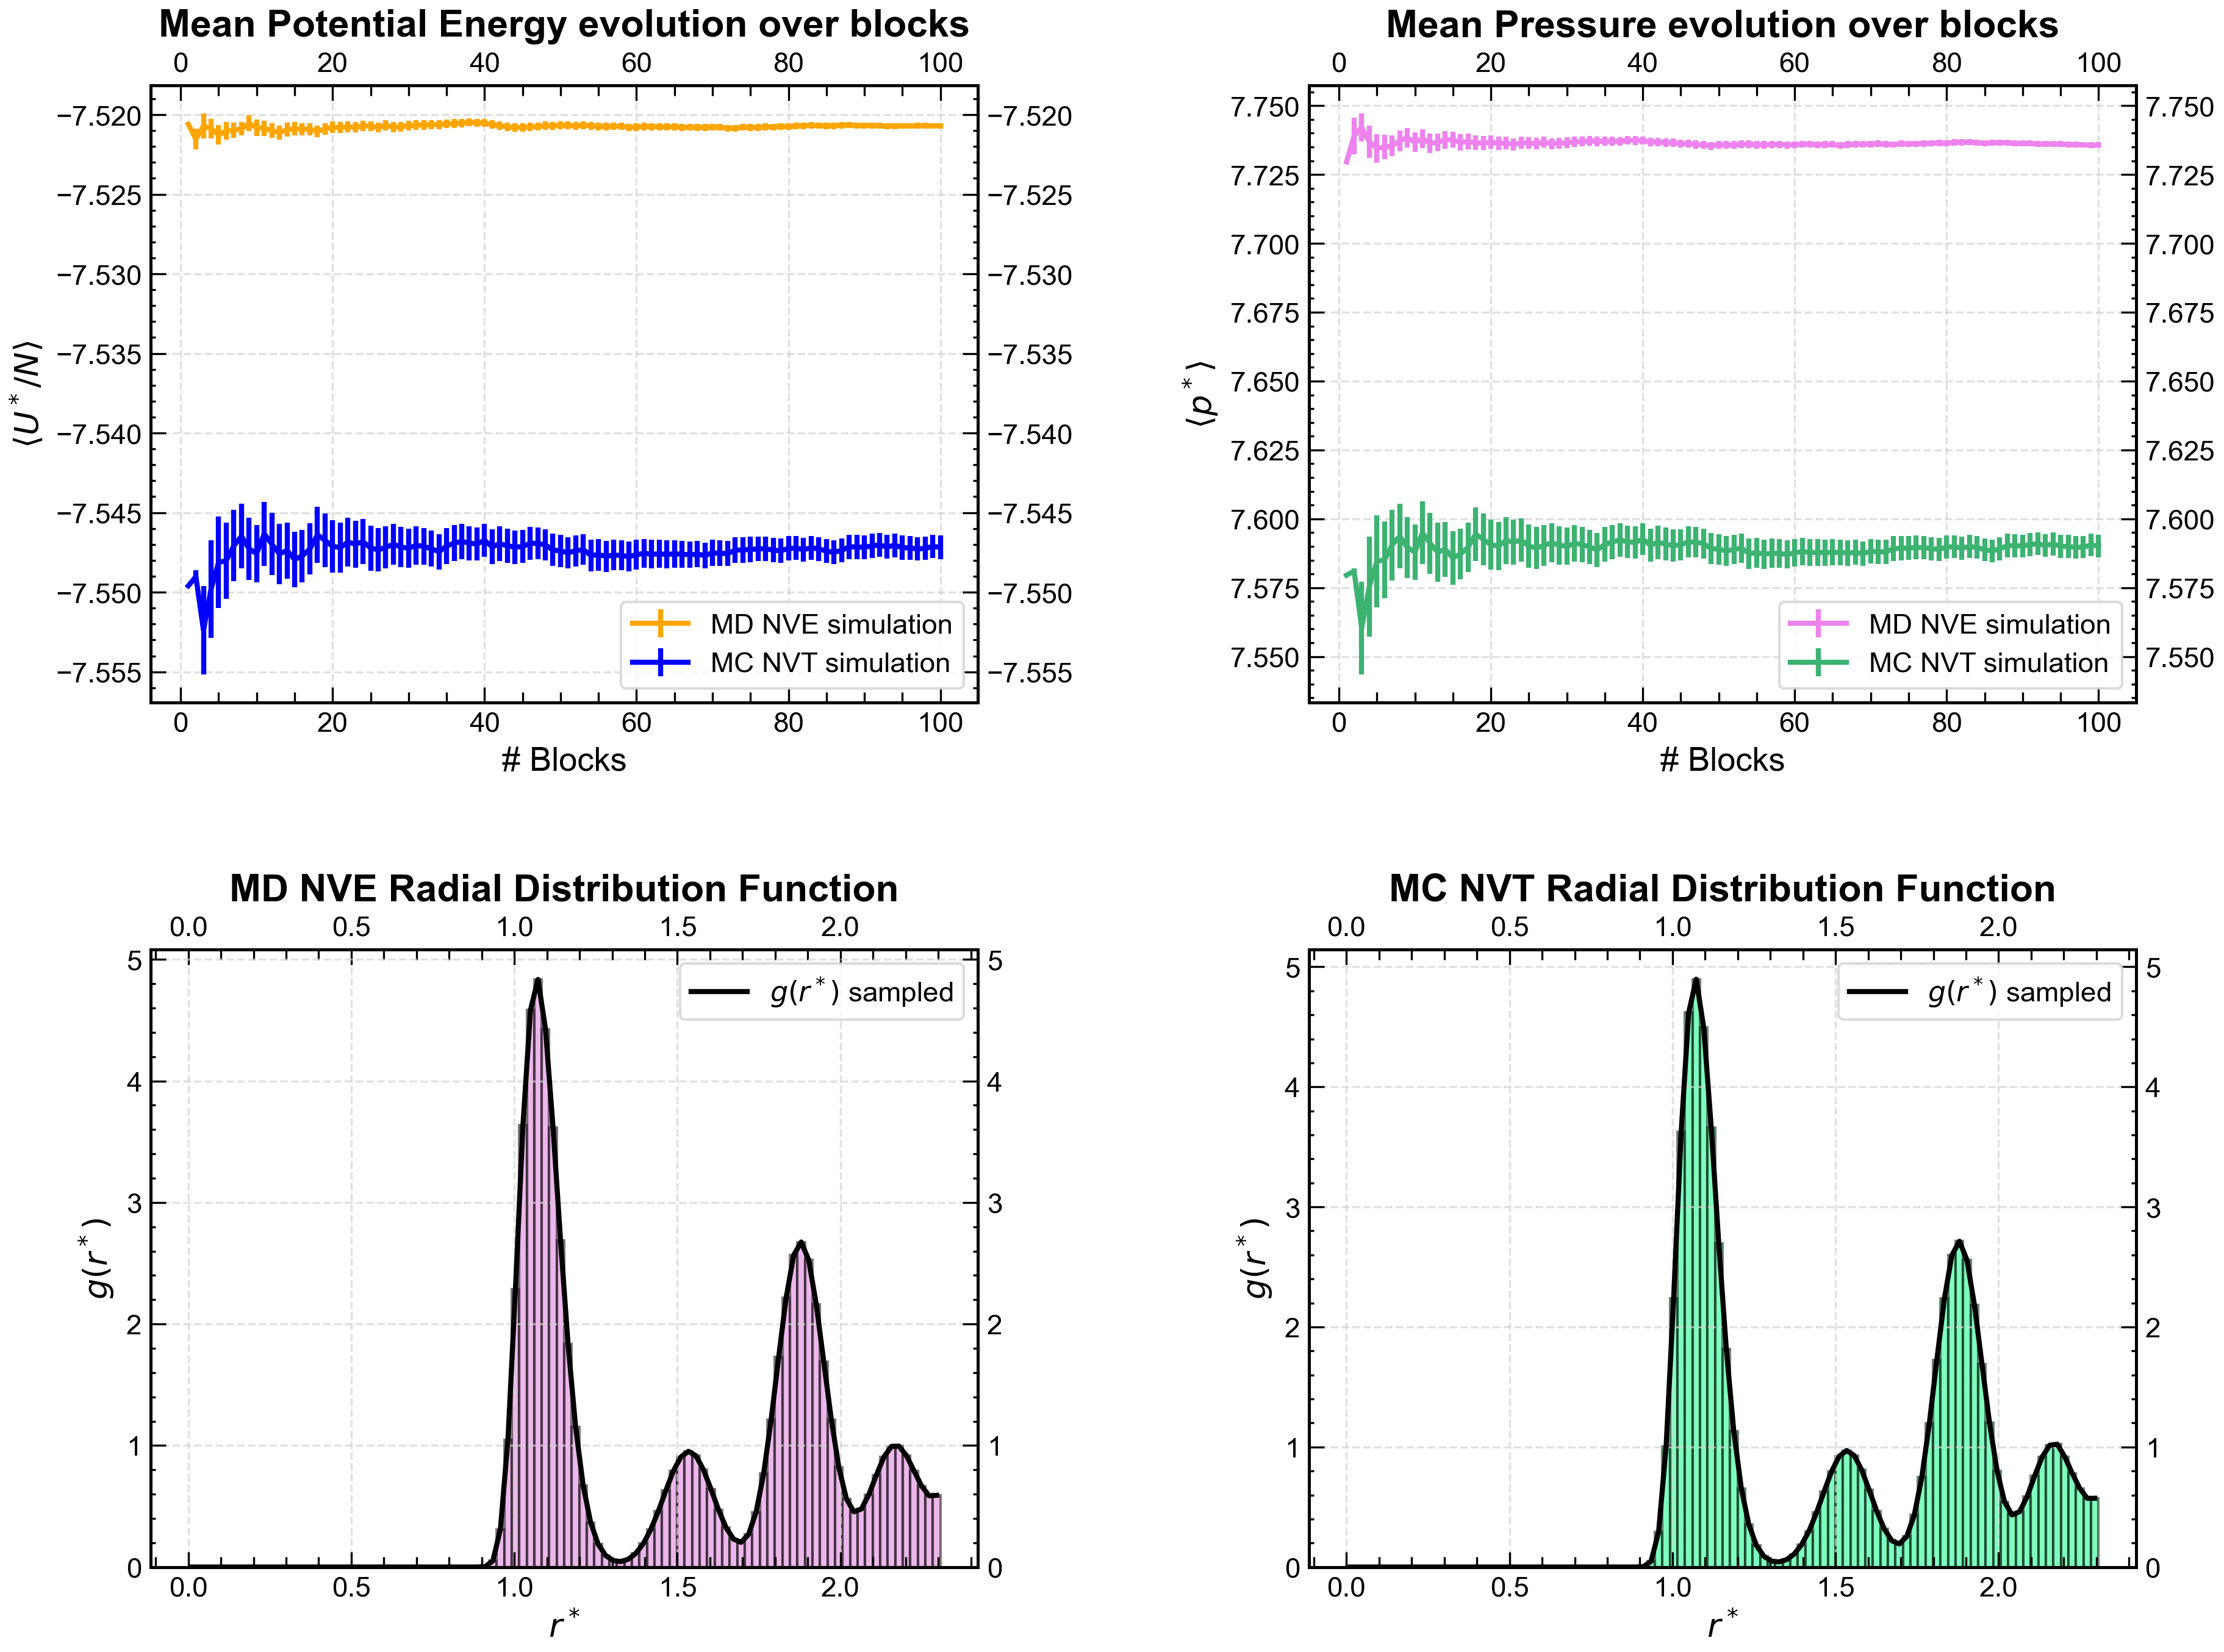

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0][0].set_title("Mean Potential Energy evolution over blocks")
axs[0][0].set_xlabel("# Blocks")
axs[0][0].set_ylabel(r"$\langle U^*/N \rangle$")
axs[0][0].errorbar(blocks, pot_en_NVE, yerr=pot_en_err_NVE, color = "orange", label="MD NVE simulation")
axs[0][0].errorbar(blocks, pot_en_NVT, yerr=pot_en_err_NVT, color = "blue", label="MC NVT simulation")
axs[0][0].legend()

axs[0][1].set_title("Mean Pressure evolution over blocks")
axs[0][1].set_xlabel("# Blocks")
axs[0][1].set_ylabel(r"$\langle p^* \rangle$")
axs[0][1].errorbar(blocks, press_NVE, yerr=press_err_NVE, color = "violet", label="MD NVE simulation")
axs[0][1].errorbar(blocks, press_NVT, yerr=press_err_NVT, color = "mediumseagreen", label="MC NVT simulation")
axs[0][1].legend()

axs[1][0].set_title("MD NVE Radial Distribution Function")
axs[1][0].set_xlabel(r"$r^*$")
axs[1][0].set_ylabel(r"$g(r^*)$")
axs[1][0].bar(bin_center, gofr_NVE, width=2*bin_center[0], alpha=0.5, color="orchid", edgecolor="black", yerr=gofr_err_NVE, ecolor="black")
axs[1][0].plot(bin_center, gofr_NVE, color="black", label=r"$g(r^*)$ sampled")
axs[1][0].legend()

axs[1][1].set_title("MC NVT Radial Distribution Function")
axs[1][1].set_xlabel(r"$r^*$")
axs[1][1].set_ylabel(r"$g(r^*)$")
axs[1][1].bar(bin_center, gofr_NVT, width=2*bin_center[0], alpha=0.5, color="springgreen", edgecolor="black", yerr=gofr_err_NVT, ecolor="black")
axs[1][1].plot(bin_center, gofr_NVT, color="black", label=r"$g(r^*)$ sampled")
axs[1][1].legend()

fig.subplots_adjust(
        wspace=0.4,  # Spazio orizzontale
        hspace=0.4, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)

fig.savefig("plot/solid/run/pe_pre_gofr.png")
plt.show()


<h4>Conclusions</h4>

Even in the case of the solid phase, the sampled RDF $g(r)$ obtained by simulating a microcanonical ensemble via MD simulations or a canonical ensemble via MCMC simulations is nearly identical. This observation verifies the hypothesis of ensemble equivalence for this structural property in large systems.

However, the behavior differs from that of the liquid phase. Firstly, the RDF does not rapidly decay to unity, but instead exhibits a long-range structural periodicity with highly pronounced peaks. This persistent structure reflects the inherent spatial order of the crystalline lattice, even at large interatomic distances, before eventually converging to $g(r) \approx 1$ at the limits of the simulation box.